total returns over the period distribution

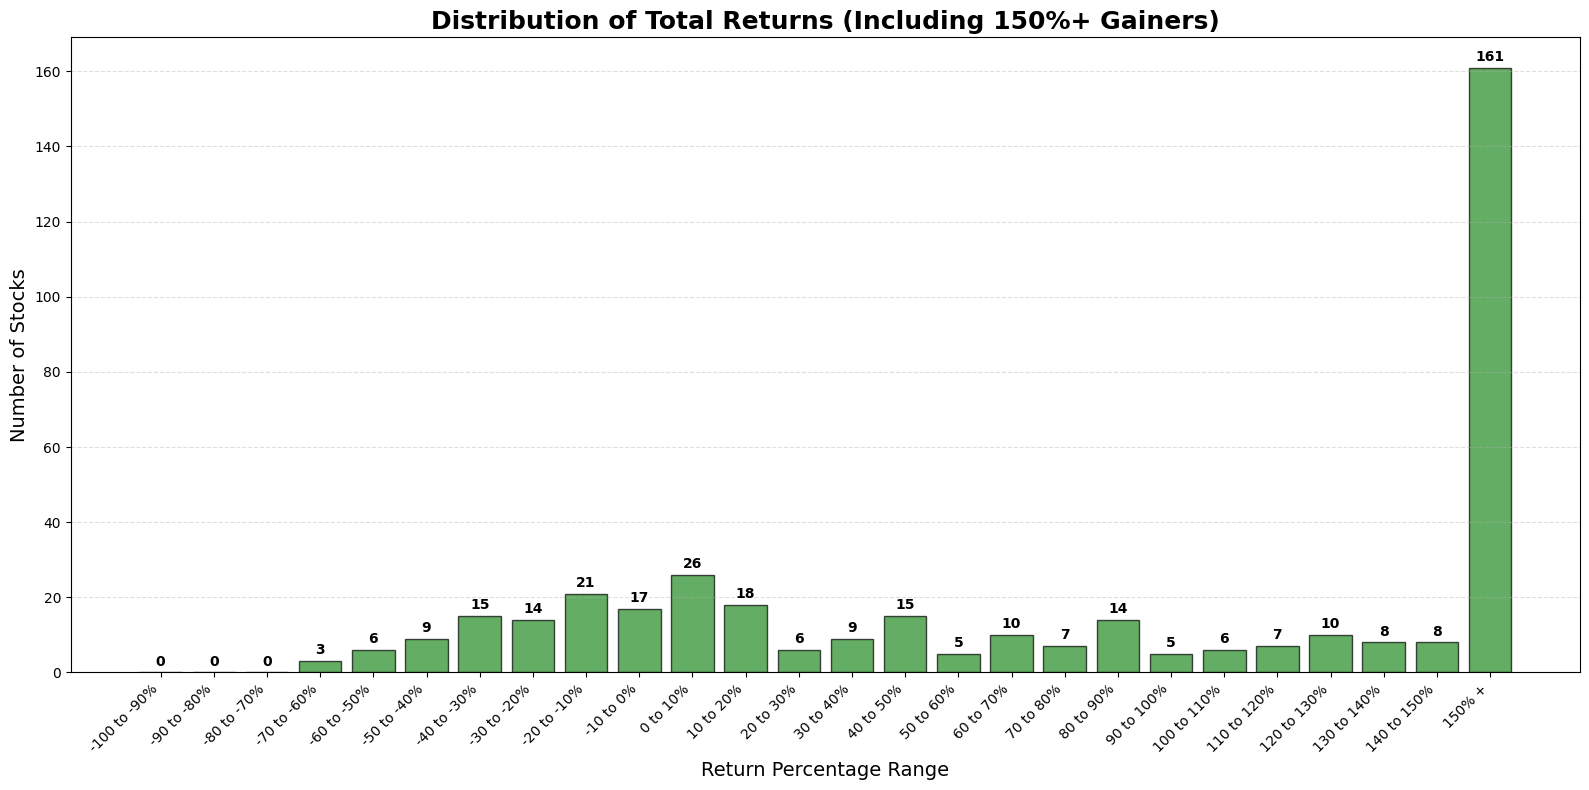

In [6]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import numpy as np

# 1. Setup path
path = r'D:\coding\financial-data-analysis\ohlcv_data_with_features'
all_files = glob.glob(os.path.join(path, "*.csv"))

all_total_returns = []

# 2. Extract first and last price for each stock
for file in all_files:
    try:
        df = pd.read_csv(file)
        df.columns = df.columns.str.strip().str.lower()
        
        if 'close' in df.columns and not df.empty:
            p_start = df['close'].iloc[0]
            p_end = df['close'].iloc[-1]
            
            if p_start != 0:
                total_return = ((p_end - p_start) / p_start) * 100
                all_total_returns.append(total_return)
    except Exception as e:
        print(f"Error processing {os.path.basename(file)}: {e}")

# 3. Define Bins: -100% to 150% in steps of 10, then catch-all for 150%+
bins = list(range(-100, 160, 10)) + [float('inf')]

# Create custom labels for the bins
labels = []
for i in range(len(bins) - 1):
    if bins[i+1] == float('inf'):
        labels.append("150% +")
    else:
        labels.append(f"{bins[i]} to {bins[i+1]}%")

# 4. Bin the data
returns_series = pd.Series(all_total_returns)
binned_data = pd.cut(returns_series, bins=bins, labels=labels, right=False).value_counts().sort_index()

# 5. Generate the Plot
plt.figure(figsize=(16, 8))
bars = plt.bar(binned_data.index, binned_data.values, color='forestgreen', edgecolor='black', alpha=0.7)

# Add value labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, int(yval), ha='center', va='bottom', fontweight='bold')

plt.title('Distribution of Total Returns (Including 150%+ Gainers)', fontsize=18, fontweight='bold')
plt.xlabel('Return Percentage Range', fontsize=14)
plt.ylabel('Number of Stocks', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

distribution of stocks who have returns over 150 percent

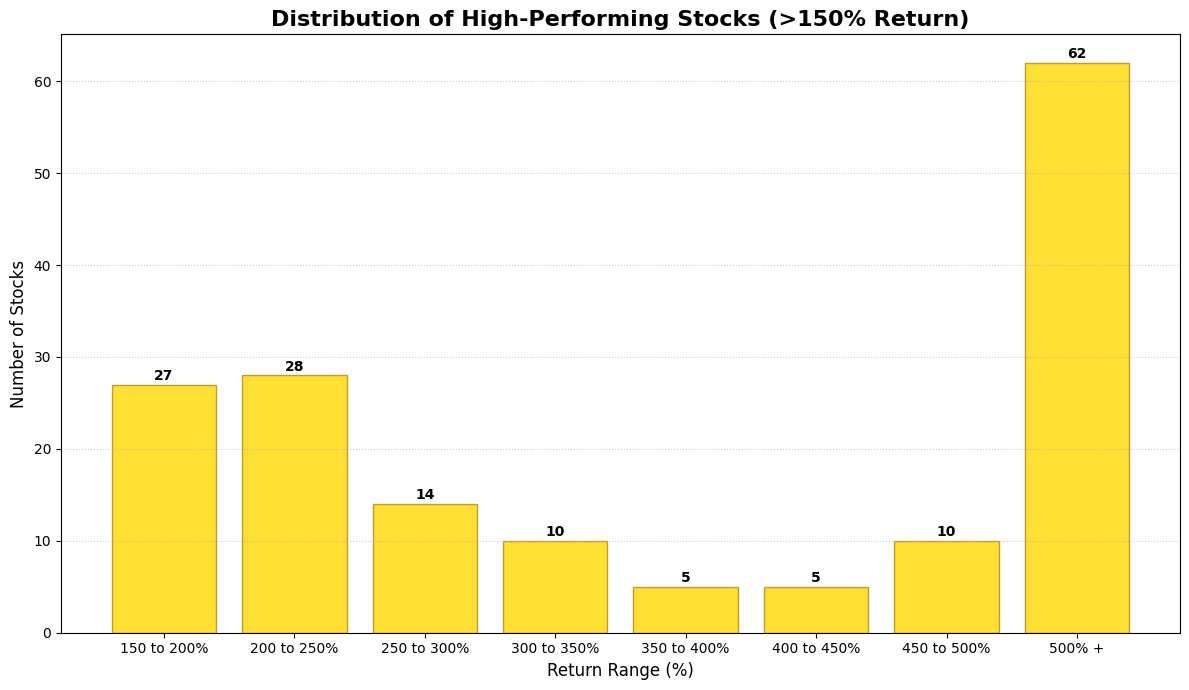

In [7]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt

# 1. Setup path
path = r'D:\coding\financial-data-analysis\ohlcv_data_with_features'
all_files = glob.glob(os.path.join(path, "*.csv"))

all_total_returns = []

# 2. Extract returns
for file in all_files:
    try:
        df = pd.read_csv(file)
        df.columns = df.columns.str.strip().str.lower()
        if 'close' in df.columns and not df.empty:
            p_start, p_end = df['close'].iloc[0], df['close'].iloc[-1]
            if p_start != 0:
                all_total_returns.append(((p_end - p_start) / p_start) * 100)
    except Exception:
        continue

# 3. Filter for only stocks > 150%
high_returns = [r for r in all_total_returns if r > 150]

# 4. Define bins for high performers (50% increments)
# Range from 150 to 500, then a catch-all for 500%+
bins = list(range(150, 550, 50)) + [float('inf')]
labels = []
for i in range(len(bins) - 1):
    if bins[i+1] == float('inf'):
        labels.append("500% +")
    else:
        labels.append(f"{bins[i]} to {bins[i+1]}%")

# 5. Binning
high_series = pd.Series(high_returns)
binned_data = pd.cut(high_series, bins=bins, labels=labels, right=False).value_counts().sort_index()

# 6. Plotting
plt.figure(figsize=(12, 7))
bars = plt.bar(binned_data.index, binned_data.values, color='gold', edgecolor='darkgoldenrod', alpha=0.8)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.2, int(yval), ha='center', va='bottom', fontweight='bold')

plt.title('Distribution of High-Performing Stocks (>150% Return)', fontsize=16, fontweight='bold')
plt.xlabel('Return Range (%)', fontsize=12)
plt.ylabel('Number of Stocks', fontsize=12)
plt.grid(axis='y', linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

--- Statistical Summary ---
Mean Return:   274.87%
Median Return: 99.06%
Mode Return:   -48.70%
Count:         400 stocks


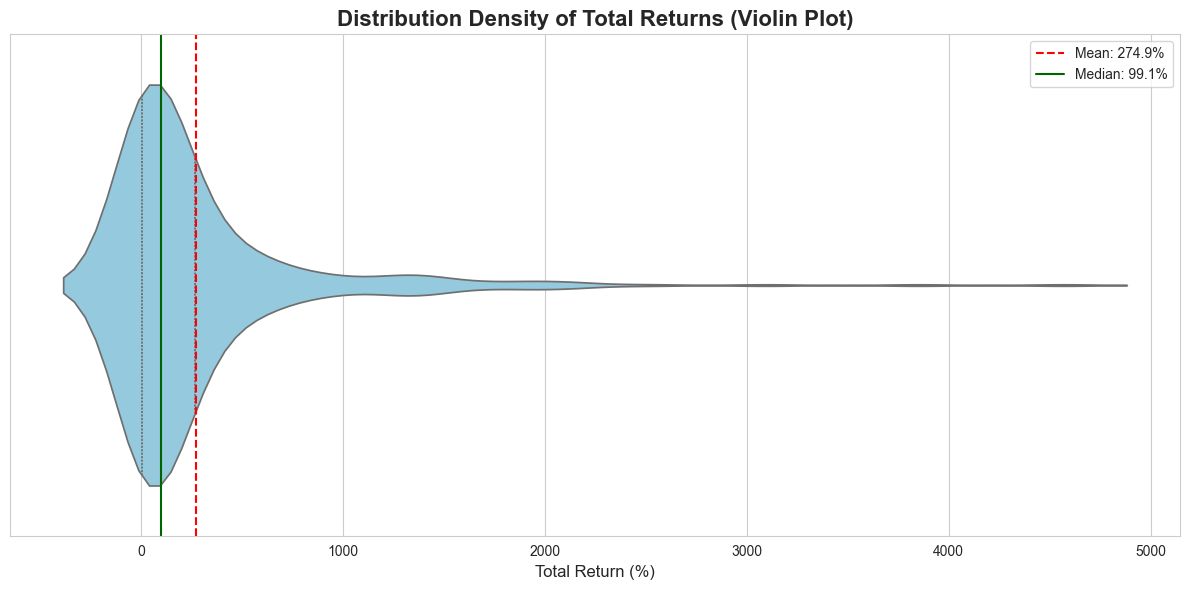

In [8]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Setup path
path = r'D:\coding\financial-data-analysis\ohlcv_data_with_features'
all_files = glob.glob(os.path.join(path, "*.csv"))

all_total_returns = []

# 2. Extract total returns
for file in all_files:
    try:
        df = pd.read_csv(file)
        df.columns = df.columns.str.strip().str.lower()
        if 'close' in df.columns and not df.empty:
            p_start, p_end = df['close'].iloc[0], df['close'].iloc[-1]
            if p_start != 0:
                all_total_returns.append(((p_end - p_start) / p_start) * 100)
    except Exception:
        continue

# Convert to a Pandas Series for easy stats
returns_series = pd.Series(all_total_returns)

# 3. Calculate Numerical Statistics
mean_val = returns_series.mean()
median_val = returns_series.median()
# Mode is calculated on rounded values (to 1 decimal) to find the most common range
mode_val = returns_series.round(1).mode()[0] 

print(f"--- Statistical Summary ---")
print(f"Mean Return:   {mean_val:.2f}%")
print(f"Median Return: {median_val:.2f}%")
print(f"Mode Return:   {mode_val:.2f}%")
print(f"Count:         {len(returns_series)} stocks")

# 4. Create the Violin Plot
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Create the violin plot
sns.violinplot(x=returns_series, color='skyblue', inner='quartile')

# Add vertical lines to mark Mean and Median on the plot
plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.1f}%')
plt.axvline(median_val, color='darkgreen', linestyle='-', label=f'Median: {median_val:.1f}%')

plt.title('Distribution Density of Total Returns (Violin Plot)', fontsize=16, fontweight='bold')
plt.xlabel('Total Return (%)', fontsize=12)
plt.legend()

# Optional: Limit x-axis if there are extreme outliers that squash the plot
# plt.xlim(-100, 500) 

plt.tight_layout()
plt.show()

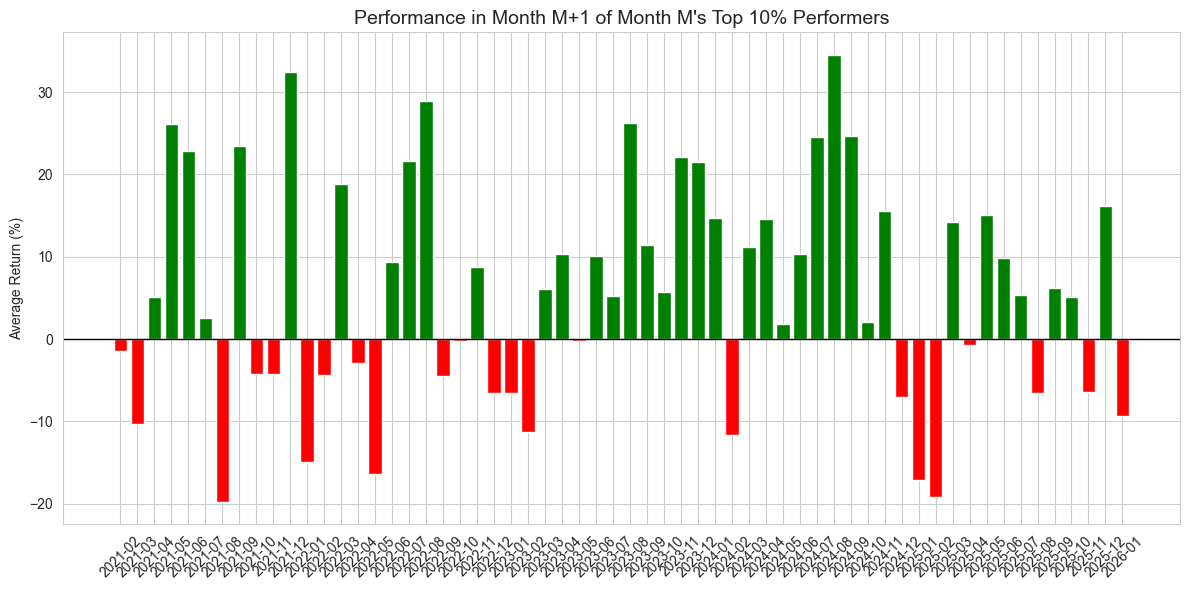

      Month  Follow_up_Return
0   2021-02         -1.471215
1   2021-03        -10.262576
2   2021-04          5.124172
3   2021-05         26.079970
4   2021-06         22.838859
5   2021-07          2.558484
6   2021-08        -19.768811
7   2021-09         23.498904
8   2021-10         -4.213351
9   2021-11         -4.182159
10  2021-12         32.472890
11  2022-01        -14.975222
12  2022-02         -4.341946
13  2022-03         18.898927
14  2022-04         -2.909638
15  2022-05        -16.368729
16  2022-06          9.336654
17  2022-07         21.667040
18  2022-08         28.890818
19  2022-09         -4.508056
20  2022-10         -0.263006
21  2022-11          8.730727
22  2022-12         -6.491764
23  2023-01         -6.595894
24  2023-02        -11.245142
25  2023-03          6.074500
26  2023-04         10.301760
27  2023-05         -0.196084
28  2023-06         10.092851
29  2023-07          5.200700
30  2023-08         26.200944
31  2023-09         11.436991
32  2023-1

In [31]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt

path = r'D:\coding\financial-data-analysis\ohlcv_data_with_features'
all_files = glob.glob(os.path.join(path, "*.csv"))

# 1. Load and prepare all data into a master long-format dataframe
all_data = []
for file in all_files:
    try:
        df = pd.read_csv(file)
        df.columns = df.columns.str.strip().str.lower()
        df['date'] = pd.to_datetime(df['date'])
        df['ticker'] = os.path.basename(file).replace('.csv', '')
        # Only keep what we need to save memory
        all_data.append(df[['date', 'ticker', 'close']])
    except:
        continue

master_df = pd.concat(all_data)
master_df['month'] = master_df['date'].dt.to_period('M')

# 2. Calculate Monthly Returns for every stock
monthly_prices = master_df.groupby(['ticker', 'month'])['close'].agg(['first', 'last'])
monthly_returns = ((monthly_prices['last'] - monthly_prices['first']) / monthly_prices['first']) * 100
monthly_returns = monthly_returns.reset_index().rename(columns={0: 'return'})

# 3. Track Performance of Top Performers
results = []
months = sorted(monthly_returns['month'].unique())

for i in range(len(months) - 1):
    current_month = months[i]
    next_month = months[i+1]
    
    # Get returns for current month and pick top 10%
    curr_data = monthly_returns[monthly_returns['month'] == current_month]
    top_threshold = curr_data['return'].quantile(0.99)
    top_tickers = curr_data[curr_data['return'] >= top_threshold]['ticker']
    
    # Track how these specific tickers did NEXT month
    next_data = monthly_returns[(monthly_returns['month'] == next_month) & 
                                (monthly_returns['ticker'].isin(top_tickers))]
    
    avg_return_next_month = next_data['return'].mean()
    results.append({'Month': str(next_month), 'Follow_up_Return': avg_return_next_month})

# 4. Plot the Result
res_df = pd.DataFrame(results)
plt.figure(figsize=(12, 6))
plt.bar(res_df['Month'], res_df['Follow_up_Return'], 
        color=['green' if x > 0 else 'red' for x in res_df['Follow_up_Return']])
plt.axhline(0, color='black', linewidth=1)
plt.title('Performance in Month M+1 of Month M\'s Top 10% Performers', fontsize=14)
plt.ylabel('Average Return (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(res_df)

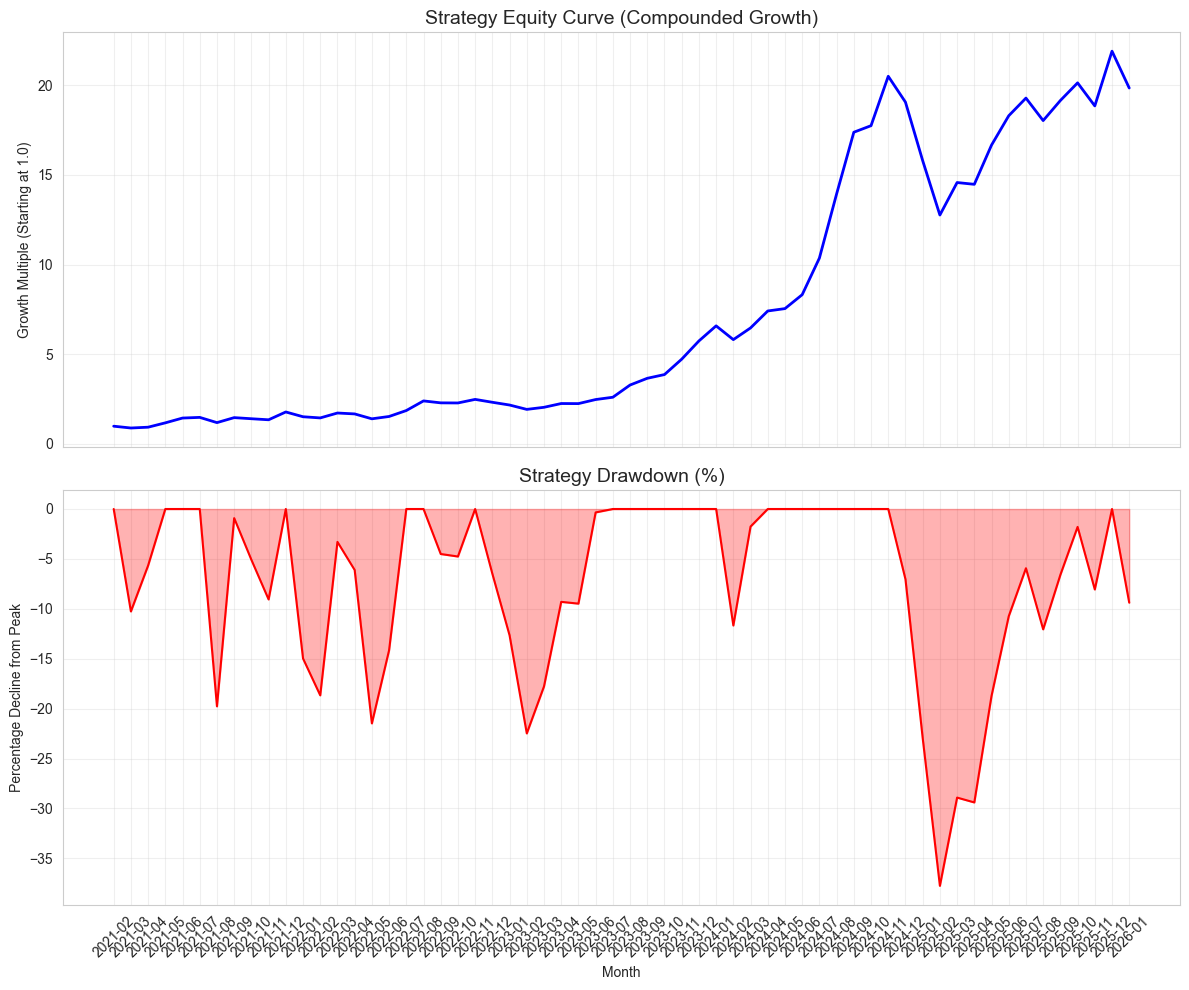

Maximum Drawdown (MDD): -37.75%


In [33]:

res_df['Equity_Curve'] = (1 + res_df['Follow_up_Return'] / 100).cumprod()

# 2. Calculate Drawdown
# Rolling maximum of the equity curve
res_df['Peak'] = res_df['Equity_Curve'].cummax()
# Drawdown = (Current Value / Peak Value) - 1
res_df['Drawdown'] = (res_df['Equity_Curve'] / res_df['Peak']) - 1

# 3. Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Plot Cumulative Growth
ax1.plot(res_df['Month'], res_df['Equity_Curve'], color='blue', lw=2)
ax1.set_title('Strategy Equity Curve (Compounded Growth)', fontsize=14)
ax1.set_ylabel('Growth Multiple (Starting at 1.0)')
ax1.grid(True, alpha=0.3)

# Plot Drawdown
ax2.fill_between(res_df['Month'], res_df['Drawdown'] * 100, 0, color='red', alpha=0.3)
ax2.plot(res_df['Month'], res_df['Drawdown'] * 100, color='red', lw=1.5)
ax2.set_title('Strategy Drawdown (%)', fontsize=14)
ax2.set_ylabel('Percentage Decline from Peak')
ax2.set_xlabel('Month')
ax2.grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Print the Maximum Drawdown
max_dd = res_df['Drawdown'].min() * 100
print(f"Maximum Drawdown (MDD): {max_dd:.2f}%")

In [34]:
# 1. Determine the number of months in the strategy
num_months = len(res_df)
num_years = num_months / 12

# 2. Calculate CAGR
# Initial Value is 1.0; Final Value is the last point on the Equity_Curve
final_value = res_df['Equity_Curve'].iloc[-1]
cagr = (final_value ** (1 / num_years)) - 1

# 3. Additional Metric: Annualized Volatility (Standard Deviation of returns * sqrt(12))
ann_vol = (res_df['Follow_up_Return'] / 100).std() * (12**0.5)

# 4. Display the results
print(f"--- Strategy Performance Metrics ---")
print(f"Total Months:         {num_months}")
print(f"Total Return:         {(final_value - 1) * 100:.2f}%")
print(f"CAGR:                 {cagr * 100:.2f}%")
print(f"Annualized Vol:       {ann_vol * 100:.2f}%")
print(f"Max Drawdown:         {max_dd:.2f}%")



--- Strategy Performance Metrics ---
Total Months:         60
Total Return:         1884.38%
CAGR:                 81.77%
Annualized Vol:       47.51%
Max Drawdown:         -37.75%
